In [1]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

from superfv import plot_1d_slice
from superfv.initial_conditions import sedov
from teyssier.sedov import sedovana
from superfv.tools.run_helper import run_multiple_simulations

In [2]:
gamma = 1.4
N = 100
T = 0.8

init_params = dict(
    ic=partial(sedov, P0=1e-5, h=1 / N, gamma=gamma),
    gamma=gamma,
    bcx=("reflective", "free"),
    nx=N,
    PAD={"rho": (0, None), "P": (0, None)},
)
run_params = dict(T=T)

In [3]:
musclhancock = dict(p=1, MUSCL=True, MUSCL_limiter="moncen")
apriori = dict(ZS=True, lazy_primitives="adaptive")
aposteriori = dict(MOOD=True, lazy_primitives="full", MUSCL_limiter="moncen")
aposteriori_1rev = dict(cascade="muscl", max_MOOD_iters=1, **aposteriori)
aposteriori_2revs = dict(cascade="muscl0", max_MOOD_iters=2, **aposteriori)
aposteriori_3revs = dict(cascade="muscl0", max_MOOD_iters=3, **aposteriori)

configs = {
    "MUSCL-Hancock": musclhancock,
    "MUSCL-RK3": musclhancock,
    "ZS3": dict(p=3, **apriori),
    "ZS7": dict(p=7, **apriori),
    "MM3/1rev/no_NAD": dict(p=3, NAD=False, SED=False, **aposteriori_1rev),
    "MM7/1rev/no_NAD": dict(p=7, NAD=False, SED=False, **aposteriori_1rev),
    "MM3/1rev/rtol_1e-1": dict(p=3, NAD_rtol=1e-1, **aposteriori_1rev),
    "MM7/1rev/rtol_1e-1": dict(p=7, NAD_rtol=1e-1, **aposteriori_1rev),
    "MM3/1rev/rtol_1e-3": dict(p=3, NAD_rtol=1e-3, **aposteriori_1rev),
    "MM7/1rev/rtol_1e-3": dict(p=7, NAD_rtol=1e-3, **aposteriori_1rev),
    "MM3/1rev/rtol_1e-5": dict(p=3, NAD_rtol=1e-5, **aposteriori_1rev),
    "MM7/1rev/rtol_1e-5": dict(p=7, NAD_rtol=1e-5, **aposteriori_1rev),
    "MM3/1rev/rtol_0": dict(p=3, NAD_rtol=0, **aposteriori_1rev),
    "MM7/1rev/rtol_0": dict(p=7, NAD_rtol=0, **aposteriori_1rev),
}

In [4]:
sims = {}


def postprocess(name, sim):
    sims[name] = sim


run_multiple_simulations(
    {
        name: (
            dict(**init_params, **config),
            dict(
                muscl_hancock=False if name == "MUSCL-RK3" else True,
                time_degree=2 if name == "MUSCL-RK3" else None,
                **run_params,
            ),
        )
        for name, config in configs.items()
    },
    "/scratch/gpfs/jp7427/out/sedov-1d/",
    postprocess=postprocess,
)

Running simulation with config `MUSCL-Hancock`:
	__init__ parameters:
		ic: functools.partial(<function sedov at 0x15200dfe7420>, P0=1e-05, h=0.01, gamma=1.4)
		gamma: 1.4
		bcx: ('reflective', 'free')
		nx: 100
		PAD: {'rho': (0, None), 'P': (0, None)}
		p: 1
		MUSCL: True
		MUSCL_limiter: moncen
	run parameters:
		muscl_hancock: True
		time_degree: None
		T: 0.8
...
Step #306 @ t=8.00e-01 | dt=2.14e-03 | min(rho)=3.11e-02, min(P)=1.00e-05 | E_cons=2.13e-14 | (ran in 0.31s)
Successfully completed MUSCL-Hancock!


Running simulation with config `MUSCL-RK3`:
	__init__ parameters:
		ic: functools.partial(<function sedov at 0x15200dfe7420>, P0=1e-05, h=0.01, gamma=1.4)
		gamma: 1.4
		bcx: ('reflective', 'free')
		nx: 100
		PAD: {'rho': (0, None), 'P': (0, None)}
		p: 1
		MUSCL: True
		MUSCL_limiter: moncen
	run parameters:
		muscl_hancock: False
		time_degree: 2
		T: 0.8
...
Step #307 @ t=8.00e-01 | dt=1.66e-03 | min(rho)=3.11e-02, min(P)=1.00e-05 | E_cons=7.11e-15 | (ran in 0.79s)
Succes

/home/jp7427/Desktop/superfv/superfv/finite_volume_solver.py:526: UserWarning: Turning off `face_fallback` since MOOD is used.
  warnings.warn("Turning off `face_fallback` since MOOD is used.")


Step #707 @ t=8.00e-01 | dt=9.82e-05 | min(rho)=5.36e-03, min(P)=1.00e-05 | E_cons=2.13e-14 | (ran in 2.90s)
Successfully completed MM3/1rev/no_NAD!


Running simulation with config `MM7/1rev/no_NAD`:
	__init__ parameters:
		ic: functools.partial(<function sedov at 0x15200dfe7420>, P0=1e-05, h=0.01, gamma=1.4)
		gamma: 1.4
		bcx: ('reflective', 'free')
		nx: 100
		PAD: {'rho': (0, None), 'P': (0, None)}
		p: 7
		NAD: False
		SED: False
		cascade: muscl
		max_MOOD_iters: 1
		MOOD: True
		lazy_primitives: full
		MUSCL_limiter: moncen
	run parameters:
		muscl_hancock: True
		time_degree: None
		T: 0.8
...


/home/jp7427/Desktop/superfv/superfv/finite_volume_solver.py:526: UserWarning: Turning off `face_fallback` since MOOD is used.
  warnings.warn("Turning off `face_fallback` since MOOD is used.")


Step #1625 @ t=8.00e-01 | dt=6.35e-04 | min(rho)=1.74e-03, min(P)=1.47e-04 | E_cons=3.25e-05 | (ran in 6.96s)
Successfully completed MM7/1rev/no_NAD!


Running simulation with config `MM3/1rev/rtol_1e-1`:
	__init__ parameters:
		ic: functools.partial(<function sedov at 0x15200dfe7420>, P0=1e-05, h=0.01, gamma=1.4)
		gamma: 1.4
		bcx: ('reflective', 'free')
		nx: 100
		PAD: {'rho': (0, None), 'P': (0, None)}
		p: 3
		NAD_rtol: 0.1
		cascade: muscl
		max_MOOD_iters: 1
		MOOD: True
		lazy_primitives: full
		MUSCL_limiter: moncen
	run parameters:
		muscl_hancock: True
		time_degree: None
		T: 0.8
...


...

Step #307 @ t=8.00e-01 | dt=2.09e-03 | min(rho)=3.11e-02, min(P)=1.00e-05 | E_cons=7.11e-15 | (ran in 1.81s)
Successfully completed MM7/1rev/rtol_1e-5!


Running simulation with config `MM3/1rev/rtol_0`:
	__init__ parameters:
		ic: functools.partial(<function sedov at 0x15200dfe7420>, P0=1e-05, h=0.01, gamma=1.4)
		gamma: 1.4
		bcx: ('reflective', 'free')
		nx: 100
		PAD: {'rho': (0, None), 'P': (0, None)}
		p: 3
		NAD_rtol: 0
		cascade: muscl
		max_MOOD_iters: 1
		MOOD: True
		lazy_primitives: full
		MUSCL_limiter: moncen
	run parameters:
		muscl_hancock: True
		time_degree: None
		T: 0.8
...


/home/jp7427/Desktop/superfv/superfv/finite_volume_solver.py:526: UserWarning: Turning off `face_fallback` since MOOD is used.
  warnings.warn("Turning off `face_fallback` since MOOD is used.")


Step #307 @ t=8.00e-01 | dt=1.97e-03 | min(rho)=3.12e-02, min(P)=1.00e-05 | E_cons=1.42e-14 | (ran in 1.77s)
Successfully completed MM3/1rev/rtol_0!


Running simulation with config `MM7/1rev/rtol_0`:
	__init__ parameters:
		ic: functools.partial(<function sedov at 0x15200dfe7420>, P0=1e-05, h=0.01, gamma=1.4)
		gamma: 1.4
		bcx: ('reflective', 'free')
		nx: 100
		PAD: {'rho': (0, None), 'P': (0, None)}
		p: 7
		NAD_rtol: 0
		cascade: muscl
		max_MOOD_iters: 1
		MOOD: True
		lazy_primitives: full
		MUSCL_limiter: moncen
	run parameters:
		muscl_hancock: True
		time_degree: None
		T: 0.8
...


/home/jp7427/Desktop/superfv/superfv/finite_volume_solver.py:526: UserWarning: Turning off `face_fallback` since MOOD is used.
  warnings.warn("Turning off `face_fallback` since MOOD is used.")


Step #307 @ t=8.00e-01 | dt=2.09e-03 | min(rho)=3.11e-02, min(P)=1.00e-05 | E_cons=1.42e-14 | (ran in 1.80s)
Successfully completed MM7/1rev/rtol_0!




In [5]:
# analytical solution for plotting
dim = 1
E0 = 1
rho0 = 1

r, d, u, P = sedovana(gamma, dim)

r *= (E0 / rho0) ** (1.0 / (dim + 2)) * T ** (2 / (dim + 2))
d *= rho0
u *= (E0 / rho0) ** (1.0 / (dim + 2)) * T ** (-dim / (dim + 2))
P *= (E0 / rho0) ** (2.0 / (dim + 2)) * T ** (-2 * dim / (dim + 2)) * rho0

chi0=np.float64(0.97306051566207)


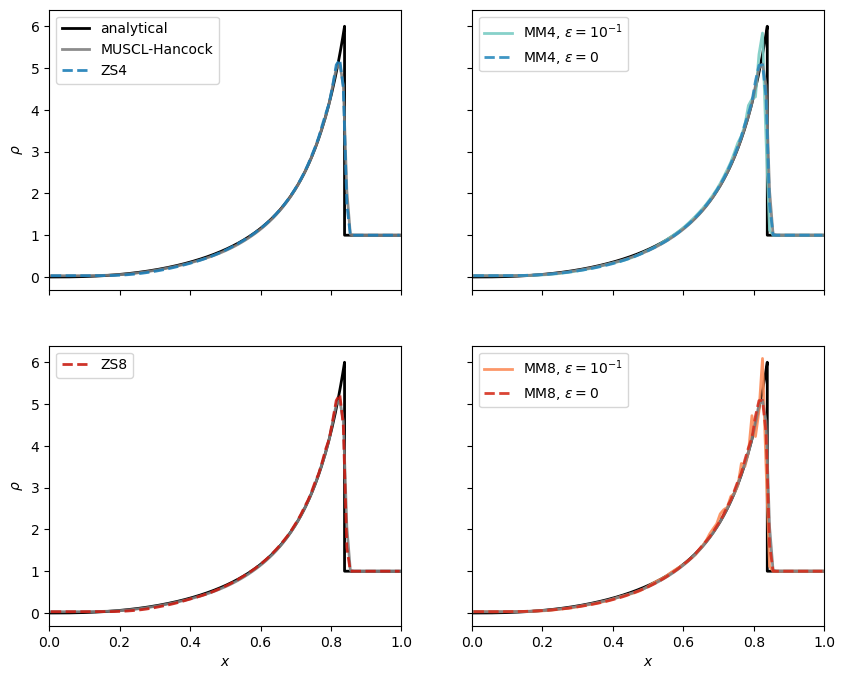

In [6]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 8))
axs[1, 0].set_xlabel(r"$x$")
axs[1, 1].set_xlabel(r"$x$")
axs[0, 0].set_ylabel(r"$\rho$")
axs[1, 0].set_ylabel(r"$\rho$")
axs[0, 0].set_xlim(0, 1)

cmap1 = plt.get_cmap("GnBu")
cmap2 = plt.get_cmap("OrRd")


common_style = dict(linewidth=2, markersize=1, mfc="none")


def plot(name, ax, v, style=dict()):
    _style = (
        dict(
            label=name,
            linestyle="--" if name == "ref" else "-",
            marker="none" if name == "ref" else "none",
            alpha=1 if name == "ref" else 0.9,
        )
        | common_style
    )
    _style.update(style)
    plot_1d_slice(sims[name], ax, v, **_style)


axs[0, 0].plot(r, d, color="k", label="analytical", **common_style)
plot("MUSCL-Hancock", axs[0, 0], "rho", dict(color="grey"))
plot("ZS3", axs[0, 0], "rho", dict(label="ZS4", linestyle="--", color=cmap1(0.8)))

axs[1, 0].plot(r, d, color="k", label="_nolegend_", **common_style)
plot("MUSCL-Hancock", axs[1, 0], "rho", dict(label="_nolegend_", color="grey"))
plot("ZS7", axs[1, 0], "rho", dict(label="ZS8", linestyle="--", color=cmap2(0.8)))

axs[0, 1].plot(r, d, color="k", label="_nolegend_", **common_style)
plot(
    "MM3/1rev/rtol_1e-1",
    axs[0, 1],
    "rho",
    dict(label=r"MM4, $\epsilon=10^{-1}$", color=cmap1(0.5)),
)
plot("MUSCL-Hancock", axs[0, 1], "rho", dict(label="_nolegend_", color="grey"))
plot(
    "MM3/1rev/rtol_0",
    axs[0, 1],
    "rho",
    dict(label=r"MM4, $\epsilon=0$", linestyle="--", color=cmap1(0.75)),
)

axs[1, 1].plot(r, d, color="k", label="_nolegend_", **common_style)
plot(
    "MM7/1rev/rtol_1e-1",
    axs[1, 1],
    "rho",
    dict(label=r"MM8, $\epsilon=10^{-1}$", color=cmap2(0.5)),
)
plot("MUSCL-Hancock", axs[1, 1], "rho", dict(label="_nolegend_", color="grey"))
plot(
    "MM7/1rev/rtol_0",
    axs[1, 1],
    "rho",
    dict(label=r"MM8, $\epsilon=0$", linestyle="--", color=cmap2(0.75)),
)


axs[0, 0].legend()
axs[0, 1].legend()
axs[1, 0].legend()
axs[1, 1].legend()

In [7]:
fig.savefig("sedov-1d.pdf")

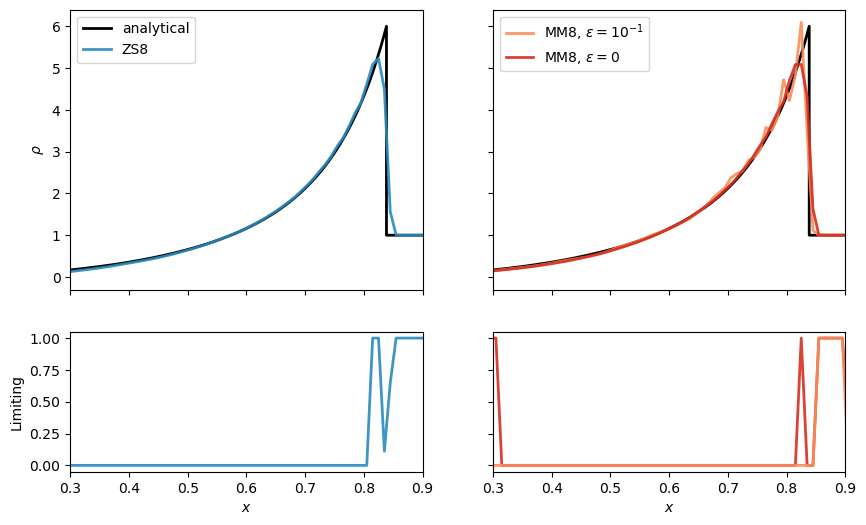

In [8]:
fig, axs = plt.subplots(
    2,
    2,
    sharex=True,
    sharey="row",
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [2, 1]},
)
axs[1, 0].set_xlabel(r"$x$")
axs[1, 1].set_xlabel(r"$x$")
axs[0, 0].set_ylabel(r"$\rho$")
axs[1, 0].set_ylabel("Limiting")
axs[0, 0].set_xlim(0.3, 0.9)

cmap1 = plt.get_cmap("GnBu")
cmap2 = plt.get_cmap("OrRd")

common_style = dict(linewidth=2, markersize=1, mfc="none")


def plot(name, ax, v, style=dict()):
    _style = dict(
        label=name,
        linestyle="--" if name == "ref" else "-",
        linewidth=2,
        markersize=1,
        marker="none" if name == "ref" else "none",
        mfc="none",
        alpha=1 if name == "ref" else 0.9,
    )
    _style.update(style)
    plot_1d_slice(sims[name], ax, v, **_style)


axs[0, 0].plot(r, d, color="k", label="analytical", **common_style)
plot(
    "ZS7",
    axs[0, 0],
    "rho",
    dict(label=r"ZS8", color=cmap1(0.75)),
)

plot(
    "ZS7",
    axs[1, 0],
    "theta",
    dict(
        label=r"ZS8",
        color=cmap1(0.75),
        multivar_func=lambda idx, _, _theta: 1
        - np.minimum(
            np.minimum(_theta[idx("rho")], _theta[idx("vx")]), _theta[idx("P")]
        ),
    ),
)

axs[0, 1].plot(r, d, color="k", label="_nolegend_", **common_style)
plot(
    "MM7/1rev/rtol_1e-1",
    axs[0, 1],
    "rho",
    dict(label=r"MM8, $\epsilon=10^{-1}$", color=cmap2(0.5)),
)
plot(
    "MM7/1rev/rtol_0",
    axs[0, 1],
    "rho",
    dict(label=r"MM8, $\epsilon=0$", color=cmap2(0.75)),
)

plot(
    "MM7/1rev/rtol_0",
    axs[1, 1],
    "cascade",
    dict(label=r"MM8, $\epsilon=0$", color=cmap2(0.75)),
)
plot(
    "MM7/1rev/rtol_1e-1",
    axs[1, 1],
    "cascade",
    dict(label=r"MM8, $\epsilon=10^{-1}$", color=cmap2(0.5)),
)

axs[0, 0].legend()
axs[0, 1].legend()

In [9]:
fig.savefig("sedov-1d-troubles.pdf")